# 5.1. - Aplicación de Filtros Clásicos

En esta sección exploraremos cómo aplicar **filtros clásicos de procesamiento de imágenes** utilizando **convolución manual** con matrices (kernels).  
El objetivo es comprender cómo actúan estos filtros sobre la intensidad de los píxeles y cómo modifican la información visual de una imagen.

Trabajaremos con tres kernels fundamentales:

- **Sobel** → para la **detección de bordes**, resaltando los cambios bruscos de intensidad.  
- **Blur (suavizado)** → para **reducir ruido** y difuminar detalles finos.  
- **Sharpen (enfoque)** → para **resaltar contornos** y mejorar la nitidez visual.

Primero aplicaremos los filtros sobre una imagen sintética sencilla (mitad blanca y mitad negra), y posteriormente sobre una imagen real, observando los efectos visuales y las diferencias entre ellos.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage import data, color, img_as_float

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (12, 6)

## Imagen sintética: mitad blanca, mitad negra

Vamos a crear una imagen sencilla de 100×200 píxeles:
- Mitad izquierda negra (0)
- Mitad derecha blanca (1)

Esto nos permitirá ver claramente cómo actúan los kernels.

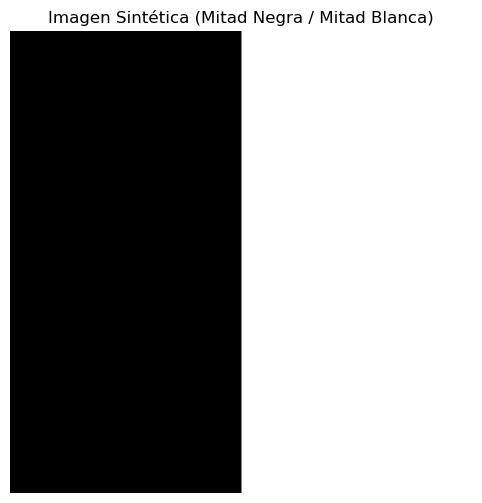

In [10]:
img_simple = np.zeros((200, 200))
img_simple[:, 100:] = 1.0  # mitad blanca

plt.imshow(img_simple, cmap='gray')
plt.title("Imagen Sintética (Mitad Negra / Mitad Blanca)")
plt.axis("off")
plt.show()

## Definición de los kernels

En procesamiento digital de imágenes, un **kernel** (o máscara de convolución) es una pequeña matriz numérica que se aplica sobre una imagen mediante una operación de **convolución**, modificando la intensidad de cada píxel según sus vecinos.  
Dependiendo de los valores del kernel, podemos resaltar bordes, suavizar zonas o aumentar el contraste.

A continuación se presentan tres de los filtros clásicos más utilizados:

---

### Filtro Sobel (detección de bordes)

El **filtro Sobel** se utiliza para detectar **bordes verticales u horizontales** en una imagen.  
Funciona midiendo los cambios bruscos de intensidad, que suelen indicar la presencia de un contorno.

En este caso aplicaremos el **Sobel en dirección X**, que resalta los bordes verticales:

$$
Sobel_x =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

El resultado muestra las zonas donde cambia la luminosidad de izquierda a derecha.

---

### Filtro Blur (suavizado)

El **filtro Blur** (o filtro de promedio) sirve para **suavizar** una imagen, reduciendo el ruido y los detalles pequeños.  
Cada píxel se reemplaza por el **promedio de sus vecinos**, lo que genera un efecto difuminado.

El kernel más común es el **promedio 3×3**:

$$
Blur =
\frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

Este filtro actúa como un promediador simple, suavizando las transiciones de intensidad.

---

### Filtro Sharpen (enfoque)

El **filtro Sharpen** tiene el efecto contrario al Blur: **aumenta el contraste** y **resalta los bordes** para mejorar la nitidez.  
Lo logra amplificando el valor del píxel central y restando la influencia de los vecinos.

Su forma más habitual es:

$$
Sharpen =
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 5 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$

Con este kernel, los bordes y detalles finos se vuelven más visibles, mientras que las zonas uniformes permanecen casi iguales.

In [11]:
# Definir kernels
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

blur = (1/9) * np.ones((3, 3))

sharpen = np.array([[0, -1, 0],
                    [-1, 5, -1],
                    [0, -1, 0]])

## Aplicar los kernels manualmente (convolución 2D)

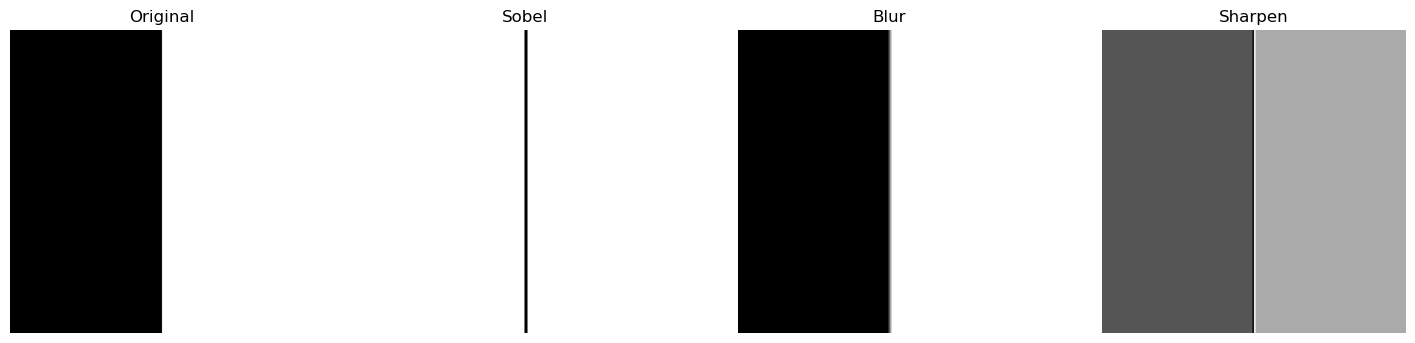

In [12]:
def aplicar_kernel(img, kernel):
    return convolve2d(img, kernel, mode='same', boundary='symm')

# Aplicamos cada kernel
img_sobel = aplicar_kernel(img_simple, sobel_x)
img_blur = aplicar_kernel(img_simple, blur)
img_sharp = aplicar_kernel(img_simple, sharpen)

# Mostramos resultados
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = ['Original', 'Sobel', 'Blur', 'Sharpen']
images = [img_simple, img_sobel, img_blur, img_sharp]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.show()

## Kernels sobre una imagen real
Usaremos una imagen real de muestra (por ejemplo, la del astronauta de `skimage`).

Primero la convertimos a escala de grises para simplificar la convolución.

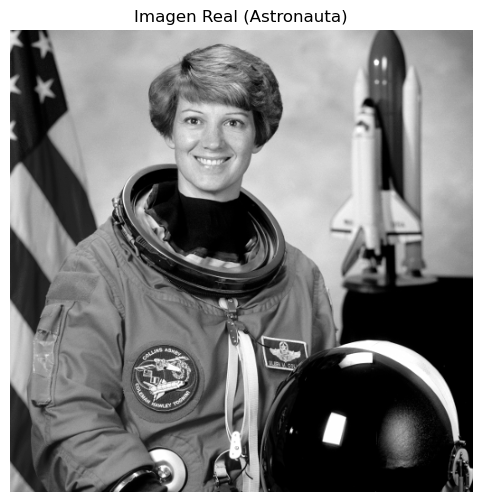

In [13]:
# Cargar imagen real y convertir a escala de grises
img_real = color.rgb2gray(data.astronaut())
img_real = img_as_float(img_real)

plt.imshow(img_real, cmap='gray')
plt.title("Imagen Real (Astronauta)")
plt.axis("off")
plt.show()

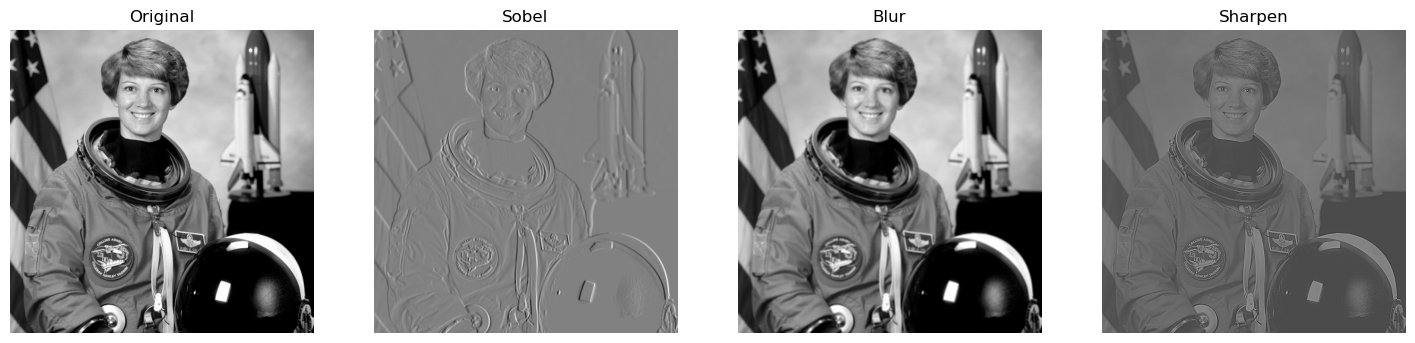

In [14]:
# Aplicamos los mismos kernels a la imagen real
img_sobel_real = aplicar_kernel(img_real, sobel_x)
img_blur_real = aplicar_kernel(img_real, blur)
img_sharp_real = aplicar_kernel(img_real, sharpen)

# Mostramos resultados
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = ['Original', 'Sobel', 'Blur', 'Sharpen']
images = [img_real, img_sobel_real, img_blur_real, img_sharp_real]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.show()

## Conclusión
- El **filtro Sobel** resalta los bordes verticales (donde cambia la intensidad).
- El **Blur** suaviza la imagen reduciendo el ruido o los detalles.
- El **Sharpen** realza los contornos y detalles, “enfocando” la imagen.

Cada uno se logra mediante convolución con un kernel diferente aplicado sobre los píxeles.